In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
data_path = './Data/kc_house_data.csv'
df = pd.read_csv(data_path)
df.drop_duplicates(inplace=True)

In [3]:
train_df = df.copy()

In [4]:
df.shape, train_df.shape

((21613, 21), (21613, 21))

In [5]:
train_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [7]:
train_df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
train_df.drop(['id'], axis=1, inplace=True)

In [9]:
train_df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [10]:
train_df['date'] = pd.to_datetime(train_df['date'], format='%Y%m%dT%H%M%S')
train_df['date']

0       2014-10-13
1       2014-12-09
2       2015-02-25
3       2014-12-09
4       2015-02-18
           ...    
21608   2014-05-21
21609   2015-02-23
21610   2014-06-23
21611   2015-01-16
21612   2014-10-15
Name: date, Length: 21613, dtype: datetime64[us]

In [11]:
train_df['sale_year'] = train_df['date'].dt.year
train_df['sale_month'] = train_df['date'].dt.month
train_df.drop(['date'], axis=1, inplace=True)
train_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [12]:
train_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,...,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,2014.322954,6.574423
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,0.467616,3.115308
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,2014.000000,4.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,2014.000000,6.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000


In [13]:
train_df['bedrooms'].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [14]:
train_df = train_df[train_df['bedrooms'] <= 10]
train_df.shape

(21611, 21)

In [15]:
train_df['price'].describe()

count    2.161100e+04
mean     5.400844e+05
std      3.671435e+05
min      7.500000e+04
25%      3.217250e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [16]:
Q1 = train_df['price'].quantile(0.01)
Q3 = train_df['price'].quantile(0.99)
train_df = train_df[(train_df['price'] >= Q1) & (train_df['price'] <= Q3)]
train_df.shape

(21177, 21)

In [17]:
train_df['house_age'] = train_df['sale_year'] - train_df['yr_built']
train_df['house_age'].head()

0    59
1    63
2    82
3    49
4    28
Name: house_age, dtype: int64

In [18]:
train_df['is_renovated'] = (train_df['yr_renovated'] > 0).astype(int)
train_df['is_renovated'].value_counts()

is_renovated
0    20302
1      875
Name: count, dtype: int64

In [19]:
train_df['living_lot_ratio'] = train_df['sqft_living'] / (train_df['sqft_lot'] + 1)
train_df['living_lot_ratio'].head()

0    0.208813
1    0.354825
2    0.076992
3    0.391922
4    0.207895
Name: living_lot_ratio, dtype: float64

In [20]:
train_df['grade_sqft'] = train_df['grade'] * train_df['sqft_living']
train_df['grade_sqft'].head()

0     8260
1    17990
2     4620
3    13720
4    13440
Name: grade_sqft, dtype: int64

In [21]:
train_df.isnull().sum()

price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
sale_year           0
sale_month          0
house_age           0
is_renovated        0
living_lot_ratio    0
grade_sqft          0
dtype: int64

In [22]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 21177 entries, 0 to 21612
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             21177 non-null  float64
 1   bedrooms          21177 non-null  int64  
 2   bathrooms         21177 non-null  float64
 3   sqft_living       21177 non-null  int64  
 4   sqft_lot          21177 non-null  int64  
 5   floors            21177 non-null  float64
 6   waterfront        21177 non-null  int64  
 7   view              21177 non-null  int64  
 8   condition         21177 non-null  int64  
 9   grade             21177 non-null  int64  
 10  sqft_above        21177 non-null  int64  
 11  sqft_basement     21177 non-null  int64  
 12  yr_built          21177 non-null  int64  
 13  yr_renovated      21177 non-null  int64  
 14  zipcode           21177 non-null  int64  
 15  lat               21177 non-null  float64
 16  long              21177 non-null  float64
 17  sqft_livi

In [23]:
corr = train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
corr

price               1.000000
grade_sqft          0.720287
grade               0.675484
sqft_living         0.673408
sqft_living15       0.597894
sqft_above          0.578485
bathrooms           0.497139
lat                 0.358723
view                0.342940
bedrooms            0.313283
sqft_basement       0.279167
floors              0.271833
waterfront          0.143976
living_lot_ratio    0.142920
yr_renovated        0.120480
is_renovated        0.120087
sqft_lot            0.097716
sqft_lot15          0.087800
yr_built            0.053748
long                0.038688
condition           0.031622
sale_year           0.005984
sale_month         -0.015861
zipcode            -0.042320
house_age          -0.053649
Name: price, dtype: float64

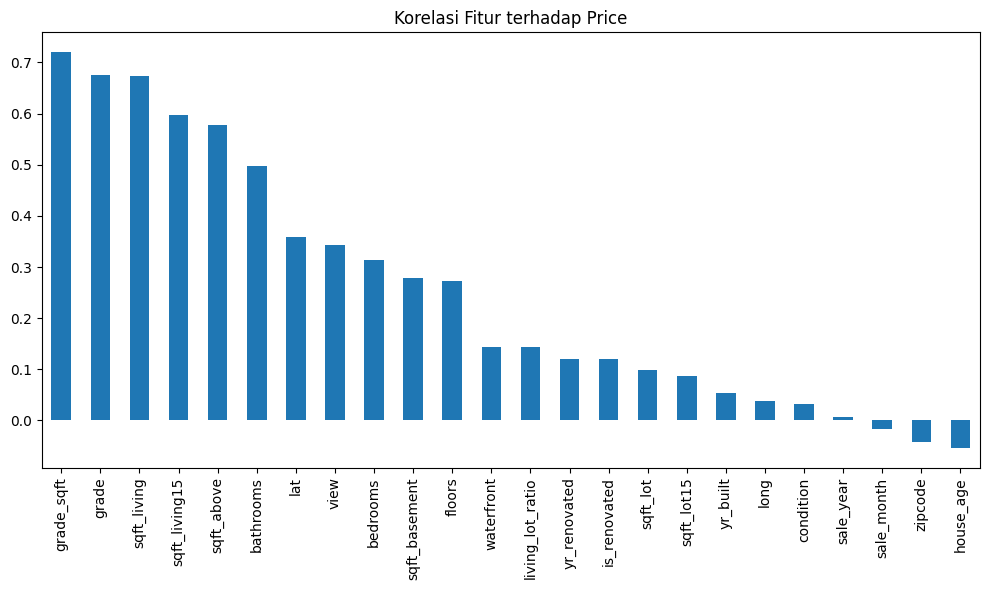

In [24]:
plt.figure(figsize=(10, 6))
corr.drop('price').plot(kind='bar')
plt.title('Korelasi Fitur terhadap Price')
plt.tight_layout()
plt.show()

In [25]:
train_df.to_csv('./Data/clean.csv', index=False)
print('Shape:', train_df.shape)

Shape: (21177, 25)
